# Sensitivity Analysis (win-rate vs N_eff sample size)

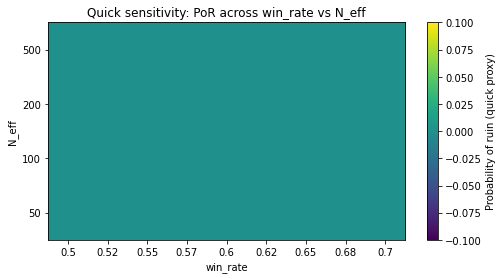

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# quick sensitivity: vary win_rate and N_eff and compute PoR (using a tiny MC for speed)
from scipy.stats import beta as beta_dist

def quick_porp(win_rate_obs, N_eff, trials=200, days=252, initial_balance=1e5, max_loss=2000, profit_rr=None, loss_rr=None):
    # simple proxy: sample win_rates and simulate quick final equity using average rr
    if profit_rr is None:
        profit_rr = np.array([1.9])
    if loss_rr is None:
        loss_rr = np.array([1.02])
    wins = int(round(win_rate_obs * N_eff))
    losses = N_eff - wins
    alpha = 1 + wins
    beta_param = 1 + losses
    sampled = beta_dist.rvs(alpha, beta_param, size=trials)
    finals = []
    for r in sampled:
        bal = initial_balance
        for _ in range(days):
            if np.random.rand() < r:
                bal += profit_rr[np.random.randint(len(profit_rr))] * max_loss
            else:
                bal -= loss_rr[np.random.randint(len(loss_rr))] * max_loss
        finals.append(bal)
    return np.mean(np.array(finals) <= 0)

win_rates = np.linspace(0.5, 0.7, 9)
N_eff_grid = [50, 100, 200, 500]
por_matrix = np.zeros((len(N_eff_grid), len(win_rates)))
for i, N_eff in enumerate(N_eff_grid):
    for j, wr in enumerate(win_rates):
        por_matrix[i, j] = quick_porp(wr, N_eff)

plt.figure(figsize=(8,4))
plt.imshow(por_matrix, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Probability of ruin (quick proxy)')
plt.yticks(range(len(N_eff_grid)), N_eff_grid)
plt.xticks(range(len(win_rates)), np.round(win_rates,2))
plt.xlabel('win_rate')
plt.ylabel('N_eff')
plt.title('Quick sensitivity: PoR across win_rate vs N_eff')
plt.show()
